In [1]:
import sys
sys.path.append('..')

In [2]:
# Random Forest jako model bazowy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from scripts.prepare_data import download_data, preproces_baseline_forest
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import RandomOverSampler


/home/kuba/RNN-ECG-analysis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = download_data()
X_train, X_test, y_train, y_test = preproces_baseline_forest(df)

In [4]:
forest = RandomForestClassifier()
forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
y_pred = forest.predict(X_test)

In [6]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average=None, zero_division=0)
rec = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy {acc}")
print(f"Precison {prec}")
print(f"Recall {rec}")
print(f"F1 {f1}")

Accuracy 0.9963863992033006
Precison [0.99859898 0.98809524 0.94010417 0.64864865]
Recall [0.99804618 0.996      0.92091837 0.54545455]
F1 0.8783398347818514


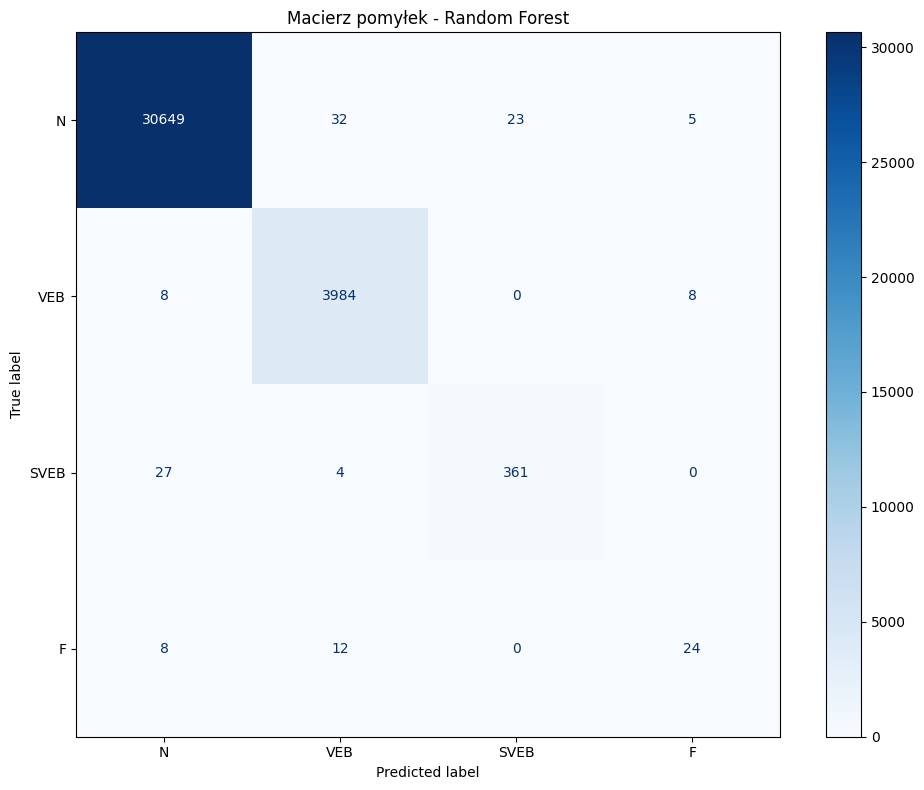

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
class_names = ['N', 'VEB', 'SVEB', 'F']

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Macierz pomyłek - Random Forest')
plt.tight_layout()
plt.show()

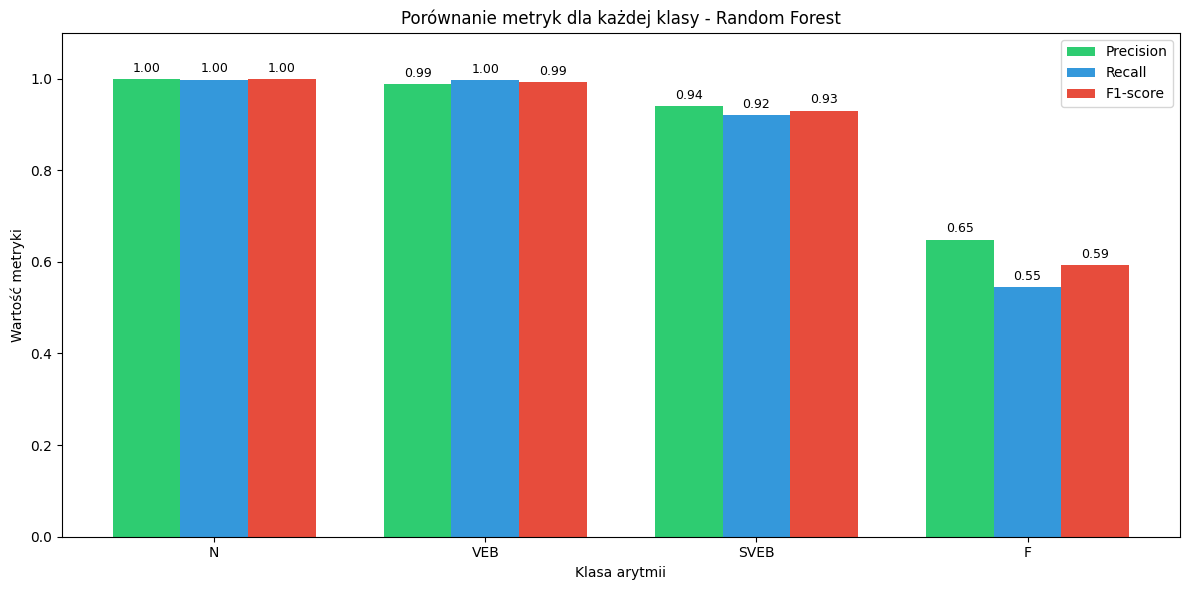

In [8]:
# Metryki per klasa - wykres słupkowy
precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, precision_per_class, width, label='Precision', color='#2ecc71')
bars2 = ax.bar(x, recall_per_class, width, label='Recall', color='#3498db')
bars3 = ax.bar(x + width, f1_per_class, width, label='F1-score', color='#e74c3c')

ax.set_xlabel('Klasa arytmii')
ax.set_ylabel('Wartość metryki')
ax.set_title('Porównanie metryk dla każdej klasy - Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.set_ylim(0, 1.1)

# Dodanie wartości nad słupkami
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

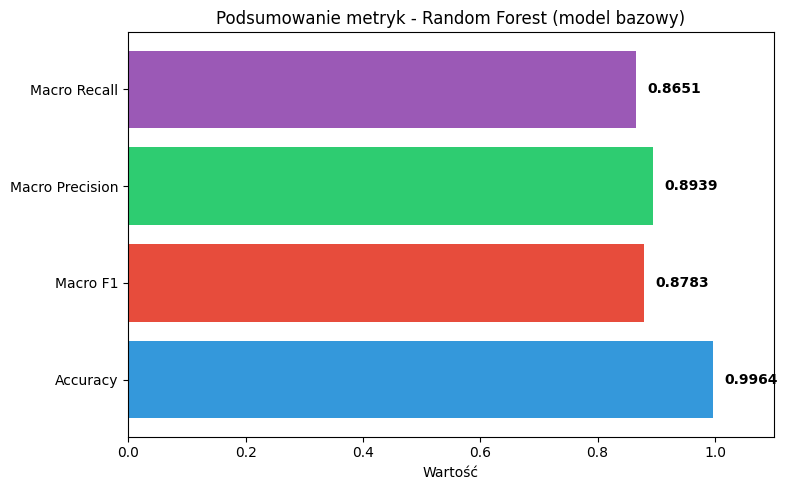


PODSUMOWANIE MODELU BAZOWEGO - RANDOM FOREST
Accuracy:        0.9964
Macro F1-score:  0.8783
Macro Precision: 0.8939
Macro Recall:    0.8651


In [9]:
# Podsumowanie metryk ogólnych
fig, ax = plt.subplots(figsize=(8, 5))

metrics_names = ['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']
macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_test, y_pred, average='macro')
metrics_values = [acc, f1, macro_precision, macro_recall]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars = ax.barh(metrics_names, metrics_values, color=colors)

ax.set_xlim(0, 1.1)
ax.set_xlabel('Wartość')
ax.set_title('Podsumowanie metryk - Random Forest (model bazowy)')

for bar, value in zip(bars, metrics_values):
    ax.text(value + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print("PODSUMOWANIE MODELU BAZOWEGO - RANDOM FOREST")
print(f"{'='*50}")
print(f"Accuracy:        {acc:.4f}")
print(f"Macro F1-score:  {f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")

1. PORÓWNANIE TRAIN vs TEST
Metryka              Train           Test            Różnica        
------------------------------------------------------------
Accuracy             1.0000          0.9964          0.0036         
Macro F1             1.0000          0.8783          0.1217         


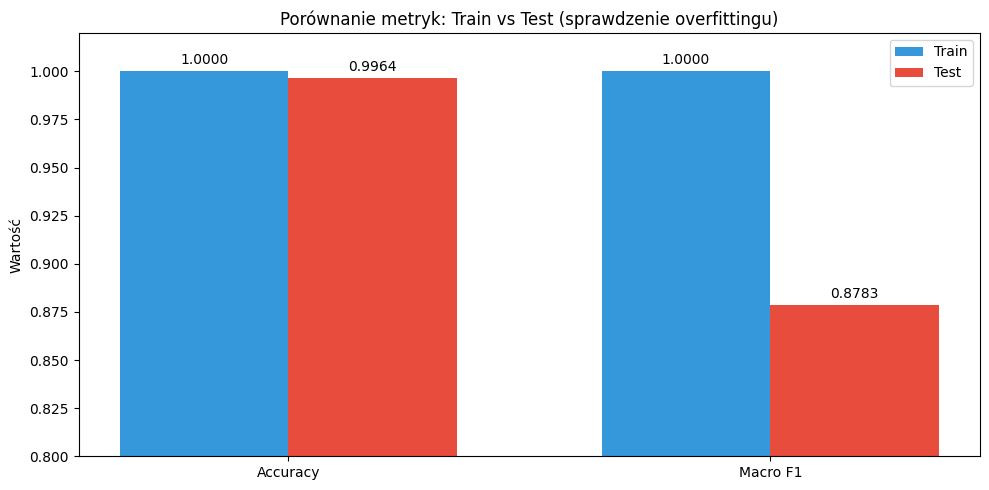


✅ Różnica między train a test jest akceptowalna.


In [10]:
# === WERYFIKACJA OVERFITTINGU ===

# 1. Porównanie wyników na zbiorze treningowym vs testowym
y_train_pred = forest.predict(X_train)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_pred, average='macro')

print("="*60)
print("1. PORÓWNANIE TRAIN vs TEST")
print("="*60)
print(f"{'Metryka':<20} {'Train':<15} {'Test':<15} {'Różnica':<15}")
print("-"*60)
print(f"{'Accuracy':<20} {train_acc:<15.4f} {test_acc:<15.4f} {train_acc - test_acc:<15.4f}")
print(f"{'Macro F1':<20} {train_f1:<15.4f} {test_f1:<15.4f} {train_f1 - test_f1:<15.4f}")

# Wizualizacja
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(2)
width = 0.35

train_metrics = [train_acc, train_f1]
test_metrics = [test_acc, test_f1]

bars1 = ax.bar(x - width/2, train_metrics, width, label='Train', color='#3498db')
bars2 = ax.bar(x + width/2, test_metrics, width, label='Test', color='#e74c3c')

ax.set_ylabel('Wartość')
ax.set_title('Porównanie metryk: Train vs Test (sprawdzenie overfittingu)')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Macro F1'])
ax.legend()
ax.set_ylim(0.8, 1.02)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

if train_acc - test_acc > 0.05:
    print("\n⚠️  UWAGA: Duża różnica między train a test - możliwy overfitting!")
else:
    print("\n✅ Różnica między train a test jest akceptowalna.")

2. CROSS-VALIDATION (5-fold)
Uwaga: To może potrwać kilka minut...

Accuracy per fold: [0.99621568 0.99641485 0.99576042 0.99664239 0.99658548]
Macro F1 per fold: [0.81831529 0.83428331 0.79521983 0.83777928 0.82295845]

Accuracy: 0.9963 (+/- 0.0006)
Macro F1: 0.8217 (+/- 0.0301)

Accuracy per fold: [0.99621568 0.99641485 0.99576042 0.99664239 0.99658548]
Macro F1 per fold: [0.81831529 0.83428331 0.79521983 0.83777928 0.82295845]

Accuracy: 0.9963 (+/- 0.0006)
Macro F1: 0.8217 (+/- 0.0301)


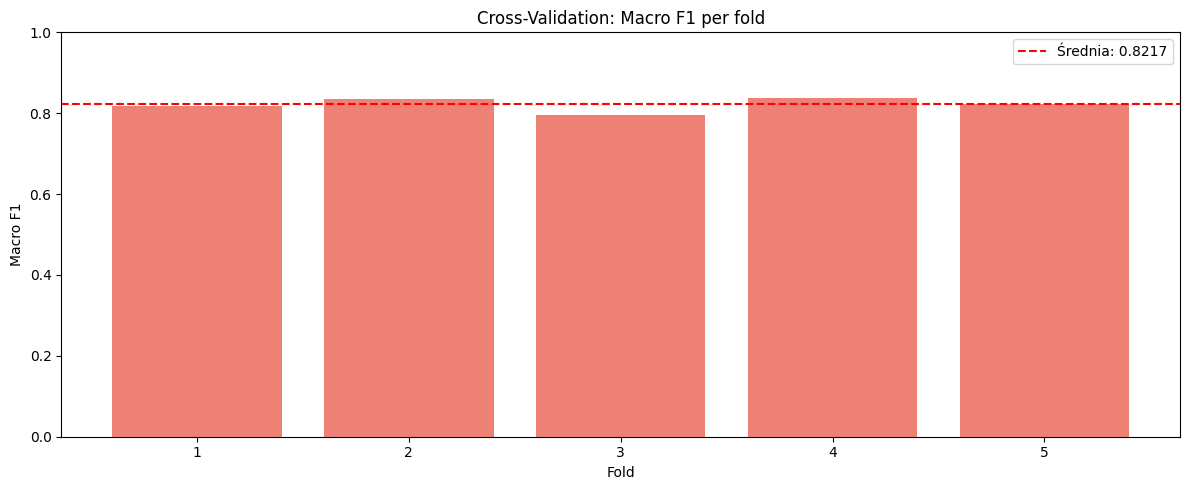

In [15]:
# 2. CROSS-VALIDATION (5-fold)
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("="*60)
print("2. CROSS-VALIDATION (5-fold)")
print("="*60)
print("Uwaga: To może potrwać kilka minut...")

# Używamy oryginalnych danych (przed oversamplingiem) do CV
# żeby uniknąć data leakage
df_cv = df.copy()
df_cv = df_cv.drop('record', axis=1)
df_cv = df_cv.dropna()
df_cv = df_cv[df_cv["type"] != 'Q']
df_cv["type"] = df_cv["type"].map({'N': 0, 'VEB': 1, 'SVEB': 2, 'F': 3})

X_cv = df_cv.drop('type', axis=1)
y_cv = df_cv['type']

# Stratified K-Fold zachowuje proporcje klas
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation z mniejszym modelem (szybciej)
forest_cv = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

cv_accuracy = cross_val_score(forest_cv, X_cv, y_cv, cv=cv, scoring='accuracy')
cv_f1 = cross_val_score(forest_cv, X_cv, y_cv, cv=cv, scoring='f1_macro')

print(f"\nAccuracy per fold: {cv_accuracy}")
print(f"Macro F1 per fold: {cv_f1}")
print(f"\nAccuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std()*2:.4f})")
print(f"Macro F1: {cv_f1.mean():.4f} (+/- {cv_f1.std()*2:.4f})")

# Wizualizacja CV
fig, axes = plt.subplots(1, 1, figsize=(12, 5))

# # Accuracy per fold
# axes[0].bar(range(1, 6), cv_accuracy, color='#3498db', alpha=0.7)
# axes[0].axhline(y=cv_accuracy.mean(), color='red', linestyle='--', label=f'Średnia: {cv_accuracy.mean():.4f}')
# axes[0].set_xlabel('Fold')
# axes[0].set_ylabel('Accuracy')
# axes[0].set_title('Cross-Validation: Accuracy per fold')
# axes[0].legend()
# axes[0].set_ylim(0.95, 1.01)

# F1 per fold
axes.bar(range(1, 6), cv_f1, color='#e74c3c', alpha=0.7)
axes.axhline(y=cv_f1.mean(), color='red', linestyle='--', label=f'Średnia: {cv_f1.mean():.4f}')
axes.set_xlabel('Fold')
axes.set_ylabel('Macro F1')
axes.set_title('Cross-Validation: Macro F1 per fold')
axes.legend()
axes.set_ylim(0, 1)

plt.tight_layout()
plt.show()

3. ANALIZA PER KLASA: TRAIN vs TEST

Klasa      Train Prec   Test Prec    Train Rec    Test Rec     Train F1     Test F1     
--------------------------------------------------------------------------------
N          1.0000       0.9986       1.0000       0.9980       1.0000       0.9983      
VEB        1.0000       0.9904       1.0000       0.9942       1.0000       0.9923      
SVEB       1.0000       0.9233       1.0000       0.9322       1.0000       0.9277      
F          1.0000       0.3871       1.0000       0.3750       1.0000       0.3810      


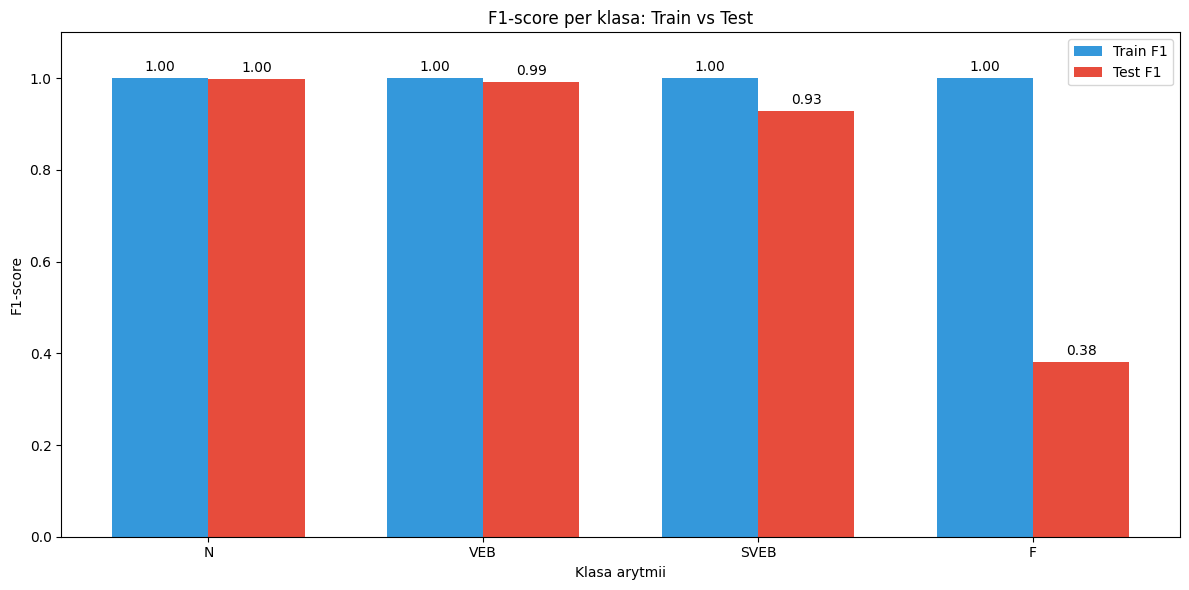

In [16]:
# 3. ANALIZA METRYK PER KLASA - TRAIN vs TEST
print("="*60)
print("3. ANALIZA PER KLASA: TRAIN vs TEST")
print("="*60)

train_precision = precision_score(y_train, y_train_pred, average=None, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, average=None)
train_f1_per_class = f1_score(y_train, y_train_pred, average=None)

test_precision = precision_score(y_test, y_pred, average=None, zero_division=0)
test_recall = recall_score(y_test, y_pred, average=None)
test_f1_per_class = f1_score(y_test, y_pred, average=None)

print(f"\n{'Klasa':<10} {'Train Prec':<12} {'Test Prec':<12} {'Train Rec':<12} {'Test Rec':<12} {'Train F1':<12} {'Test F1':<12}")
print("-"*80)
for i, cls in enumerate(class_names):
    print(f"{cls:<10} {train_precision[i]:<12.4f} {test_precision[i]:<12.4f} {train_recall[i]:<12.4f} {test_recall[i]:<12.4f} {train_f1_per_class[i]:<12.4f} {test_f1_per_class[i]:<12.4f}")

# Wizualizacja F1 per klasa: Train vs Test
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(x - width/2, train_f1_per_class, width, label='Train F1', color='#3498db')
bars2 = ax.bar(x + width/2, test_f1_per_class, width, label='Test F1', color='#e74c3c')

ax.set_xlabel('Klasa arytmii')
ax.set_ylabel('F1-score')
ax.set_title('F1-score per klasa: Train vs Test')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.set_ylim(0, 1.1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [13]:
# 4. PODSUMOWANIE ANALIZY OVERFITTINGU
print("="*60)
print("PODSUMOWANIE ANALIZY")
print("="*60)

print("Cel dla RNN - pobić F1 macro")

PODSUMOWANIE ANALIZY
Cel dla RNN - pobić F1 macro
